6. What do you think is the main computational bottleneck generating GPs in the way we did above? For regular grids, Fast Fourier transforms can be much more efficient. Use the spectral density form of the Matérn kernel from Wikipedia to make a GP. Hint: multiply the spectral density by random phases before feeding into the FFT. Does it look the same as the GPs you generated by factorizing the covariance?

I think Cholesky decomposing the covariance (Matern kernel) matrix takes the most time (it is O(n^3)).

The formula for the power spectral density is $S(f) = \lim_{T \to \infty}\frac{1}{2T}E(|X_T(\omega)|^2)$. The definition of $X_T(\omega)$ is via a Fourier Transform:

$$X_T(\omega) = \int_{-T}^{T}X(t)e^{i \omega t} dt$$

A theorem called the Wiener Kinchin Theorem shows that this is exactly the Fourier Transform of the covariance kernel: $$S(\omega) = \int_{-\infty}^{\infty} R_{xx}(\tau)e^{i \omega t}d\tau$$

(note: $R_{xx} (\tau)$ is just an arbitrary covariance kernel. $\tau$ is the distance between two points). From the power spectral density, you can reconstruct a random signal as follows: take the square root of the power spectral density and then mulitply by a random Gaussian (G(0, 1)) (?????) to get the amplitude of each frequency, tack on a random phase $0 < \phi < 2\pi$ (by multipliying by $e^{i\phi}$ because we are going to do an inverse Fourier Transform) and then "add all of these frequencies up" via the inverse Fourier transform. 

The following code (written mostly with AI, but I made sure to generally understand what it is doing) doesn't seem to work, as the amplitude of the GP still seems to be too low and the GP still seems more jittery than it should be.


Slope of best fit line between log(power) and log(omega) is -1.8850338893488938
Slope of best fit line with fft is -1.8850338893488932
The two calculated y_intercepts are -2.5253556284991303 and -2.525355628499133
The true log(power) at omega = 1 is -2.021267106767358


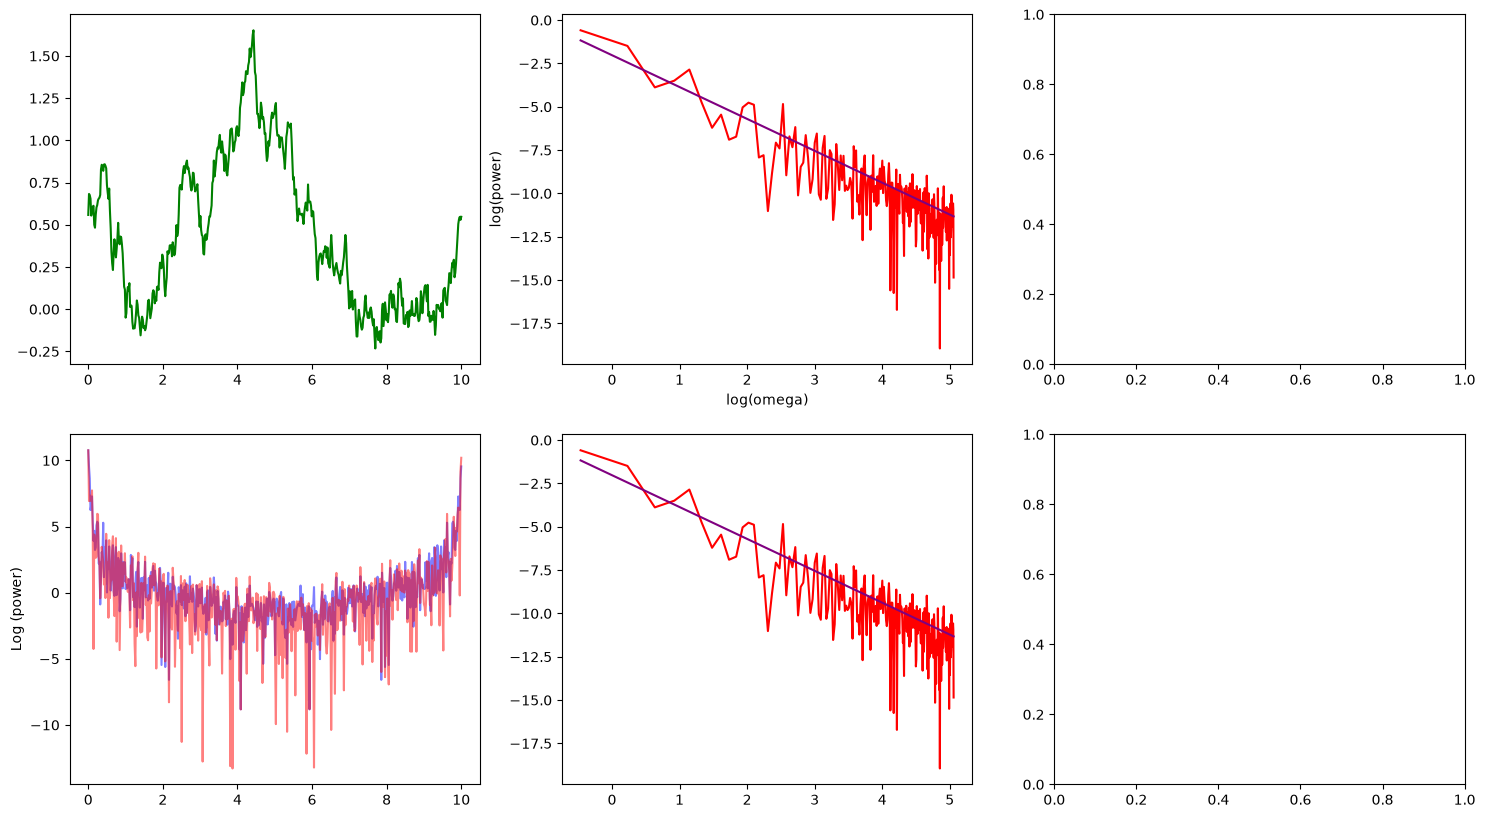

In [ ]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import jax.scipy.special as jss


import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)
rng = jr.key(8)
num_entries = 500
total_length = 10
boundary_padding = 0
num_fourier_entries = int(jnp.round(num_entries * (total_length + boundary_padding)/total_length))
normalization_factor = num_fourier_entries/jnp.sqrt(total_length + boundary_padding)
#normalization_factor = 1
linspace = jnp.linspace(0, total_length, num_entries)
half_linspace = jnp.linspace(0, total_length, num_entries // 2)
num_cholesky_samples = 10
num_fft_samples = 10



variance = 1.0
scale =20.0
nu = 0.42

rng, k1, k2 = jr.split(rng, 3)
def matern_32(r, variance=variance, scale=scale, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*jnp.abs(r)/scale)*jnp.exp(-1*jnp.sqrt(3)*jnp.abs(r)/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_entries - 1)

def matern_spectral_density(omega, variance=1.0, scale=1.0, jitter=1e-6):
    result = variance * scale * 12 * jnp.sqrt(3)/((3 + (scale*omega)**2)**2)
    return jnp.where(omega > 0, result, result * (1.0 + jitter))


def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return jnp.where(omega > 0, result, result * (1.0 + jitter))


def matern_magnitude(omega, variance, scale, nu):
    inference_params = (jnp.log(variance), jnp.log(scale), jnp.log(nu))
    return jnp.sqrt(general_matern_spectral_density(omega, inference_params))

shape = (num_entries, num_entries)
dist_matrix = jnp.fromfunction(dist_function, shape)
# I am choosing a Matern covariance with nu = 3/2 for the prior 
K = matern_32(dist_matrix)
L_K = jnp.linalg.cholesky(K)
def cholesky_field(noise):
    return L_K @ noise
freq_spacing = (total_length + boundary_padding) / num_fourier_entries
freqs = jnp.fft.fftfreq(num_fourier_entries, d=freq_spacing)
omegas = 2 * jnp.pi * freqs


# These numbers are variance, scale, nu in the green plot!
raw_average_amplitude_data = matern_magnitude(omegas, variance, scale, nu)

def fft_field(noise):
    size = noise.shape[0]
    amplitude_noise_positive_frequencies = (noise[1: size//2] + 1j * noise[size//2 + 1: size])/jnp.sqrt(2)
    amplitude_noise_negative_frequencies = jnp.conj(jnp.flip(amplitude_noise_positive_frequencies))
    amplitude_noise = jnp.concatenate([
        noise[0:1],
        amplitude_noise_positive_frequencies,
        noise[size//2: size//2 + 1],
        amplitude_noise_negative_frequencies
    ])
    amplitudes = amplitude_noise*raw_average_amplitude_data
    y_data = jnp.real(jnp.fft.ifft(amplitudes)*normalization_factor)
    return y_data[0: num_entries]


def fft_field_rfft(noise):
    size = noise.shape[0]
    half_amp = raw_average_amplitude_data[:size // 2 + 1]
    pos = (noise[1:size // 2] + 1j * noise[size // 2 + 1:size]) / jnp.sqrt(2)
    half_spectrum = jnp.concatenate([noise[0:1], pos, noise[size // 2:size // 2 + 1]]) * half_amp
    y_data = jnp.fft.irfft(half_spectrum, n=size) * normalization_factor
    return y_data[0:num_entries]

def fft_field_hartley(noise):
    size = noise.shape[0]
    H = noise * raw_average_amplitude_data         
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_entries]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fold_spectrum(X):
    N = X.shape[0]
    m = N // 2 + 1
    full_fold = ((X + jnp.roll(X[::-1], 1)) / 2)[:m]
    return full_fold[1:]

def get_spectrum(field):
    spectra_with_noise = hartley(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(spectra_with_noise**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept


def get_spectrum2(field):
    spectra_with_noise = jnp.fft.fft(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(jnp.abs(spectra_with_noise)**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept


noise_cho = jr.normal(k1, (num_cholesky_samples, num_entries))
field_cho = jax.vmap(cholesky_field)(noise_cho)
noise_fft = jr.normal(k2, (num_fft_samples, num_fourier_entries))
field_fft = jax.vmap(fft_field_hartley)(noise_fft)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

log_omegas, inferred_spectra_fft, slope, intercept = get_spectrum(field_fft[0, :])
log_omegas_2, inferred_spectra_fft_2, slope_2, intercept_2 = get_spectrum2(field_fft[0, :])
for i in range(0, 1):
    axes[0][0].plot(linspace, field_fft[i, :], color = "green", alpha = 1)
    axes[0][1].plot(log_omegas_2, inferred_spectra_fft_2, color = "red", alpha = 1 )
    axes[1][1].plot(log_omegas_2, inferred_spectra_fft_2, color = "red", alpha = 1 )
    axes[0][1].plot(log_omegas, jnp.log(fold_spectrum(matern_magnitude(omegas, variance, scale, nu)**2)), color = "purple", alpha = 1)
    axes[1][1].plot(log_omegas, jnp.log(fold_spectrum(matern_magnitude(omegas, variance, scale, nu)**2)), color = "purple", alpha = 1)
axes[0][1].set_xlabel("log(omega)")
axes[0][1].set_ylabel("log(power)")
axes[1][0].plot(linspace, jnp.log(jnp.abs(jnp.fft.fft(field_fft[0, :]))**2), color = "blue", alpha = 0.5)
axes[1][0].plot(linspace, jnp.log(jnp.abs(hartley(field_fft[0, :]))**2), color = "red", alpha = 0.5)
axes[1][0].set_ylabel("Log (power)")
print(f"Slope of best fit line between log(power) and log(omega) is {slope}")
print(f"Slope of best fit line with fft is {slope_2}")
print(f"The two calculated y_intercepts are {intercept} and {intercept_2}")
print(f"The true log(power) at omega = 1 is {jnp.log(matern_magnitude(1, variance, scale, nu)**2)}")





/home/dtfrake/hmc-dust/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/dtfrake/hmc-dust/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


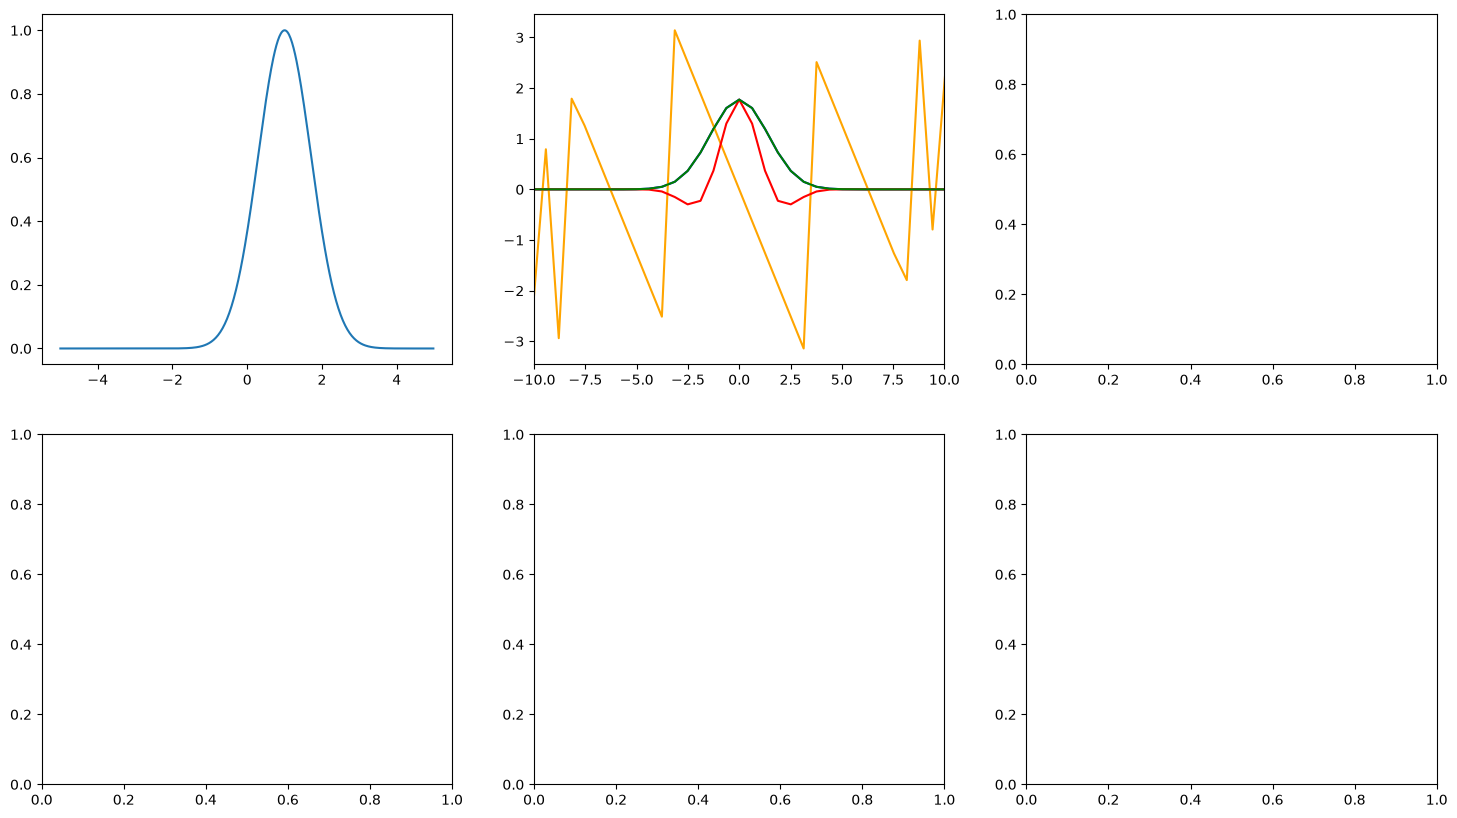

In [73]:
def toy_function(x):
    return jnp.exp(-((x - 1)**2))

T = total_length
N = num_entries
dt = T/N
x_values = -T/2 + jnp.arange(N)*dt
y_values = matern_32(x_values)
y_values_pre_fft = jnp.fft.ifftshift(y_values)
amplitudes = dt*jnp.fft.fft(y_values_pre_fft)
amplitudes_post_fft = jnp.fft.fftshift(amplitudes)
actual_omegas_arr = jnp.arange(-N/2, N/2)*2*jnp.pi/T
axes[1][2].plot(x_values, y_values, color = "green", alpha = 0.5)
axes[1][1].plot(actual_omegas_arr, jnp.abs(amplitudes_post_fft), color = "red", alpha = 0.2)
axes[1][1].plot(actual_omegas_arr, matern_spectral_density(jnp.abs(actual_omegas_arr)), color = "Purple", alpha = 0.2)
y_inverted = jnp.fft.fftshift(jnp.fft.ifft(amplitudes)/dt)
axes[1][2].plot(x_values, y_inverted, color = "blue", alpha = 0.5)

x_values = -T/2 + jnp.arange(N)*dt
y_values = toy_function(x_values)

y_values_pre_fft = jnp.fft.ifftshift(y_values)
amplitudes = dt*jnp.fft.fft(y_values_pre_fft)
amplitudes_post_fft = jnp.fft.fftshift(amplitudes)
actual_omegas_arr = jnp.arange(-N/2, N/2)*2*jnp.pi/T

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0][0].plot(x_values, y_values)
axes[0][1].plot(actual_omegas_arr, jnp.abs(amplitudes_post_fft), color = "Blue")
axes[0][1].plot(actual_omegas_arr, jnp.angle(amplitudes_post_fft), color = "Orange")
axes[0][1].plot(actual_omegas_arr, jnp.real(amplitudes_post_fft), color = "Red")
axes[0][1].plot(actual_omegas_arr, jnp.sqrt(jnp.pi) * jnp.exp(-actual_omegas_arr*actual_omegas_arr/4), color = "Green")
axes[0][1].set_xbound(-10, 10)



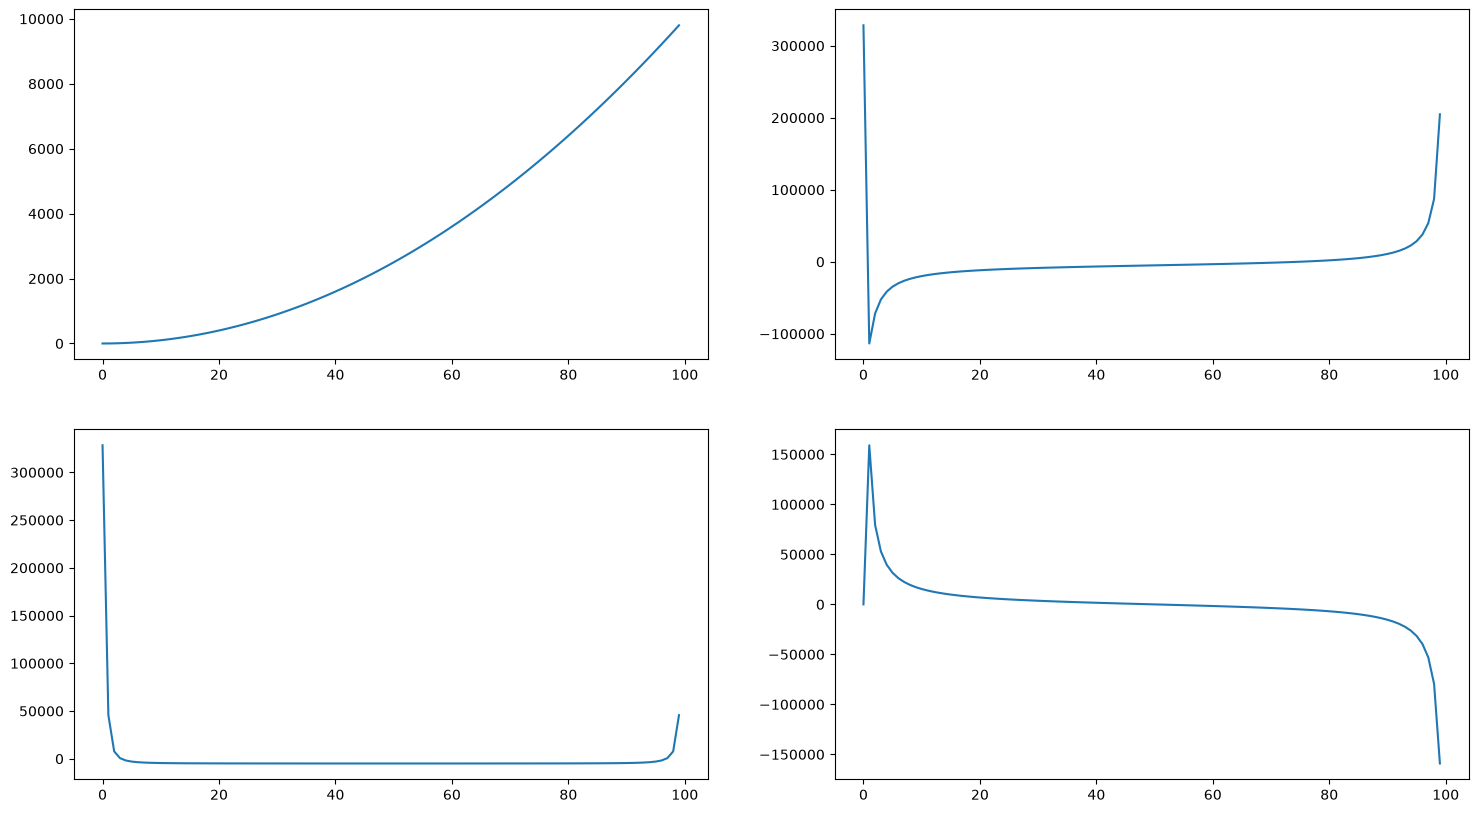

In [74]:
fig, axes = plt.subplots(2, 2, figsize = (18, 10))
x_values = jnp.arange(100)
toy_data = x_values*x_values
fft = jnp.fft.fft(toy_data)
axes[0][0].plot(x_values, toy_data)
axes[0][1].plot(x_values, jnp.real(fft) - jnp.imag(fft))
axes[1][0].plot(x_values, jnp.real(fft))
axes[1][1].plot(x_values, jnp.imag(fft))


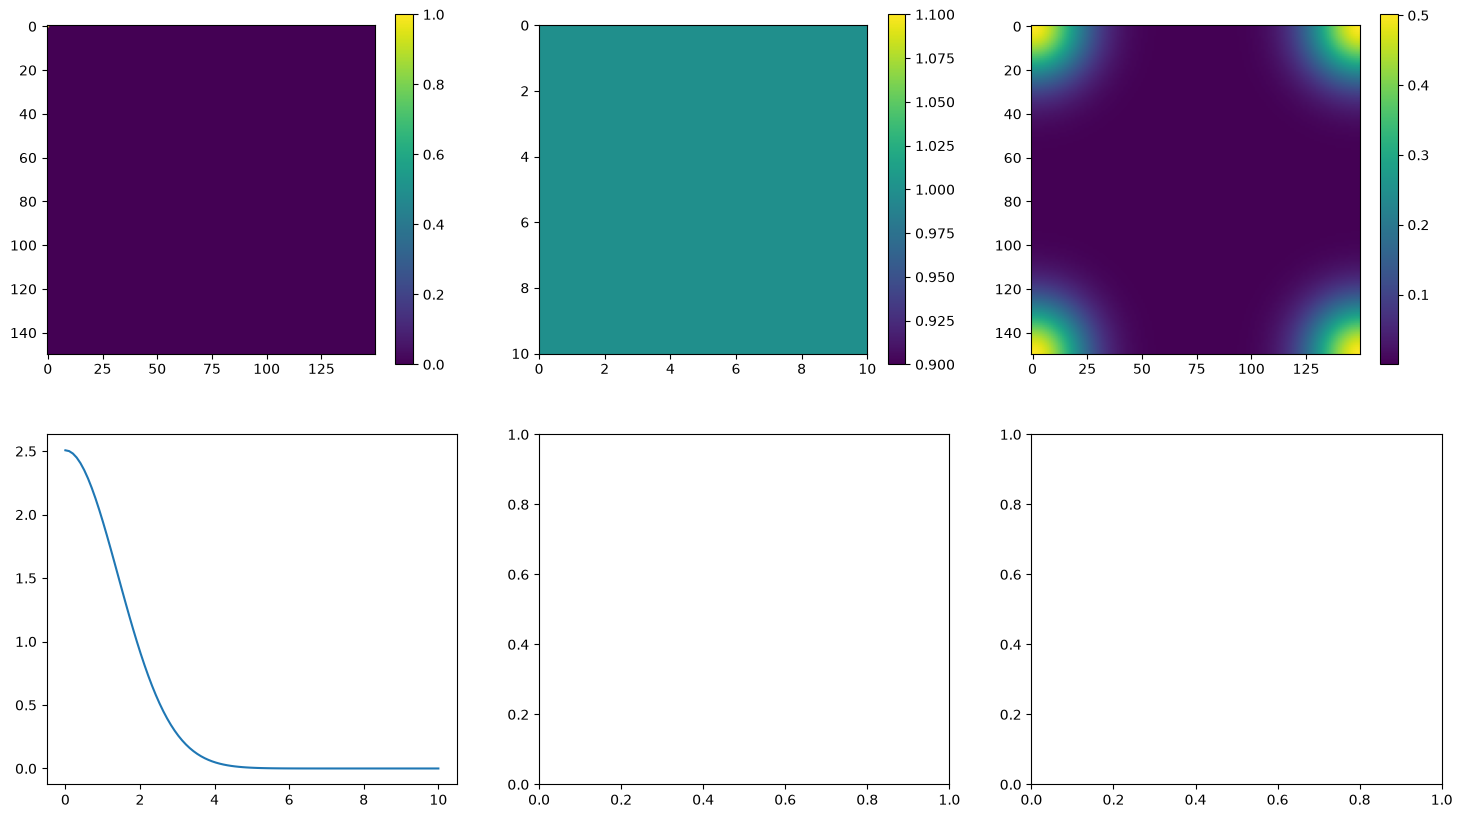

In [75]:
def matern_spectral_density_2D(omega, params):
    log_var, log_scale, log_nu = params
    ell = jnp.exp(log_scale)
    nu  = jnp.exp(log_nu)

    # x = omega^2 ell^2 / (2 nu); log1p keeps this exact as nu -> inf (SE limit)
    x = (omega * ell) ** 2 / (2.0 * nu)
    log_S = log_var + jnp.log(2.0 * jnp.pi) + 2.0 * log_scale \
            - (nu + 1.0) * jnp.log1p(x)
    return jnp.exp(log_S)


dimensions = jnp.array([100, 100])
fourier_dimensions = jnp.array([150, 150])
length = jnp.array([10, 10])
fourier_length = length*fourier_dimensions/dimensions
omegas_y = 2*jnp.pi*jnp.fft.fftfreq(fourier_dimensions[1], d = fourier_length[1]/fourier_dimensions[1])
omegas_x = 2*jnp.pi*jnp.fft.fftfreq(fourier_dimensions[0], d = fourier_length[0]/fourier_dimensions[0])
O_y, O_x = jnp.meshgrid(omegas_y, omegas_x, indexing = "ij")
O_mag = jnp.sqrt(O_y**2 + O_x**2)
spectral_density = matern_spectral_density_2D(O_mag, (0.0, jnp.log(0.2), 20))
raw_average_amplitude_data = jnp.sqrt(spectral_density)

rng = jr.PRNGKey(4)
rng, key = jr.split(rng)

hi = jr.normal(key, shape = (fourier_dimensions[0], fourier_dimensions[1]))
#raw_average_amplitude_data = jnp.ones_like(hi)

def fft_field_hartley_2d(noise):
    H = noise*raw_average_amplitude_data   
    y_data = hartley2(H)/jnp.sqrt(fourier_length[0]*fourier_length[1])
    return y_data[:dimensions[0]:, :dimensions[1]]

def hartley2(x):
    X = jnp.fft.fft2(x)
    return jnp.real(X) - jnp.imag(X)

hi = jnp.zeros(shape = (fourier_dimensions[0], fourier_dimensions[1])) 
hi = hi.at[0, 0].set(1)
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
im = axes[0][0].imshow(hi)
fig.colorbar(im, ax=axes[0][0])
im2 = axes[0][1].imshow(hartley2(hi), extent=[0, 10, 10, 0])
fig.colorbar(im2, ax = axes[0][1])
im3 = axes[0][2].imshow(jnp.sqrt(spectral_density))
fig.colorbar(im3, ax = axes[0][2])
linspace = jnp.linspace(0, 10, 100)
axes[1][0].plot(linspace, jnp.sqrt(matern_spectral_density_2D(linspace, (0.0, jnp.log(1), 5))))
plt.show()

Notes: In the Hartley transform, the square root of the Matern power spectrum basically controls the amplitude of each frequency. The noise xi does have an effect on the amplitude of the modes, but the main effect is on the phase; the phase of each k is controlled by the relative amplitudes of the xi's corresoponding to +k and -k. 